IMPORTNG LIBRARIES:-

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

LOAD THE DATASET

In [ ]:
df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape

(10000, 14)

In [ ]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


REMOVE IDENTIFYER COLUMNS:-

In [ ]:
# Remove identifier columns

df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

# Display the first five rows
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


DATA CLEANING AND DATA QUALITY ASSESSMENT

In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (10000, 11)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


checking for null values

In [ ]:
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


checking for duplicates:

In [ ]:
df.duplicated().sum()

np.int64(0)

checking unique values

In [ ]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique())


CreditScore
[619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771
 681 544 696 766 727 693 557 531 498 651 791 733 811 707 714 782 775 799
 602 744 588 747 583 627 731 629 438 642 806 474 559 429 680 749 734 644
 626 649 805 718 840 630 654 762 568 613 522 737 648 443 640 540 460 593
 801 611 802 745 483 690 492 709 705 5

In [ ]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


In [ ]:
df["Exited"].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.63
1,20.37


checking the numerical columns for outliers:-

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numerical_cols)

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


convert binary cloumns to readable lables

In [ ]:
df["Exited"] = df["Exited"].map({0: "Stayed", 1: "Exited"})

df["HasCrCard"] = df["HasCrCard"].map({0: "No", 1: "Yes"})

df["IsActiveMember"] = df["IsActiveMember"].map({0: "Inactive", 1: "Active"})

EDA PART 1: OVERALL CHURN ANALYSIS


customer churn distribution

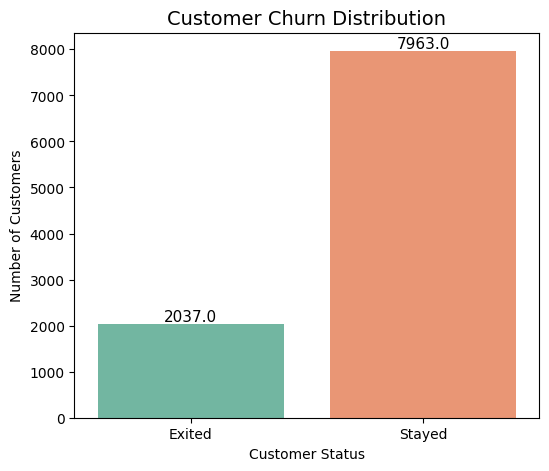

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.countplot(data=df, x="Exited", palette="Set2")

# Add labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom',
                fontsize=11)

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

customer churn percentage

In [ ]:
churn_percentage = (
    df["Exited"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Exited
Stayed    79.63
Exited    20.37
Name: proportion, dtype: float64


pie chart

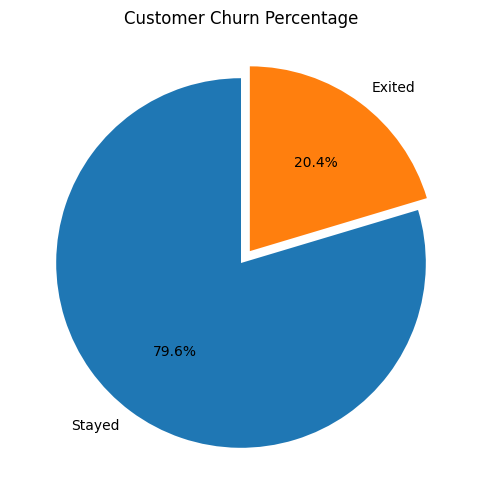

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    df["Exited"].value_counts(),
    labels=df["Exited"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0,0.08),
)

plt.title("Customer Churn Percentage")

plt.show()

EDA PART 2: DEMOGRAPHIC ANALYSIS

Which country's customers are leaving the most?

In [ ]:
churn_geo = (
    pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100
).round(2)

churn_geo

Exited,Exited,Stayed
Geography,,
France,16.15,83.85
Germany,32.44,67.56
Spain,16.67,83.33


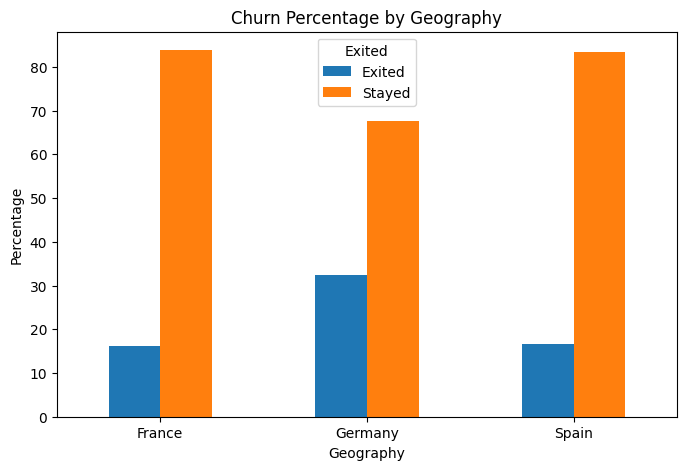

In [ ]:
churn_geo.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Percentage by Geography")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

what is the churn rate in each gender?

In [ ]:
gender_churn = (
    pd.crosstab(df["Gender"], df["Exited"], normalize="index") * 100
).round(2)

gender_churn

Exited,Exited,Stayed
Gender,,
Female,25.07,74.93
Male,16.46,83.54


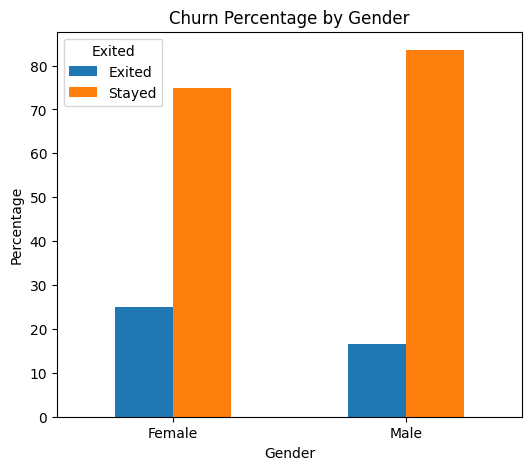

In [ ]:
gender_churn.plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Churn Percentage by Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

which age group is most likely to churn?

First, let's look at the distribution.

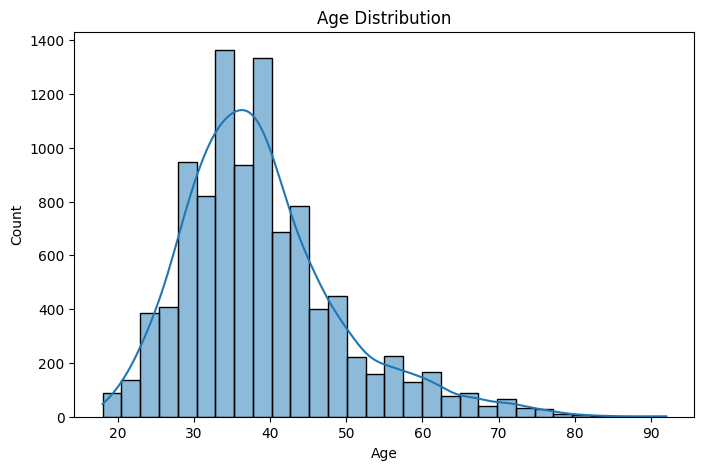

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

Now compare ages by customer status.

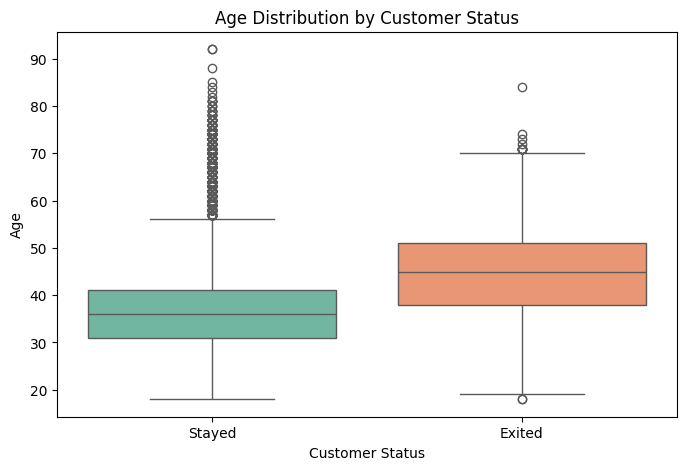

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Exited",
    y="Age",
    order=["Stayed", "Exited"],
    palette={"Stayed": "#66c2a5", "Exited": "#fc8d62"}
)

plt.title("Age Distribution by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Age")

plt.show()

claculating the average age.

In [ ]:
df.groupby("Exited")["Age"].mean().round(2)

,Age
Exited,
Exited,44.84
Stayed,37.41


EDA PART 3: CUSTOMER BEHAVIOR ANALYSIS

churn with resp to activeness of a customer

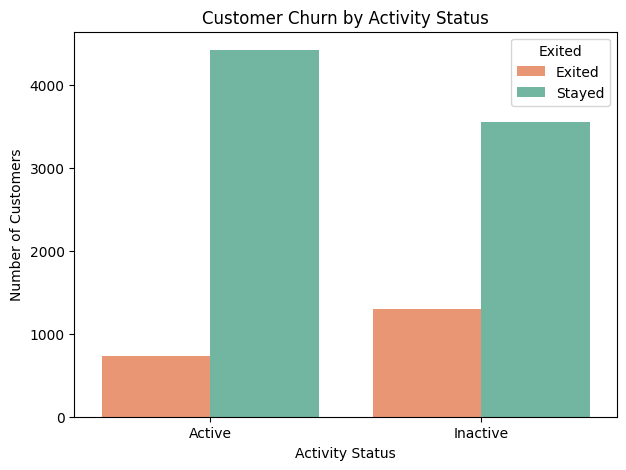

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="IsActiveMember",
    hue="Exited",
    palette={"Stayed": "#66c2a5", "Exited": "#fc8d62"}
)

plt.title("Customer Churn by Activity Status")
plt.xlabel("Activity Status")
plt.ylabel("Number of Customers")

plt.show()

churn percentage

In [ ]:
activity_churn = (
    pd.crosstab(df["IsActiveMember"], df["Exited"], normalize="index") * 100
).round(2)

activity_churn

Exited,Exited,Stayed
IsActiveMember,,
Active,14.27,85.73
Inactive,26.85,73.15


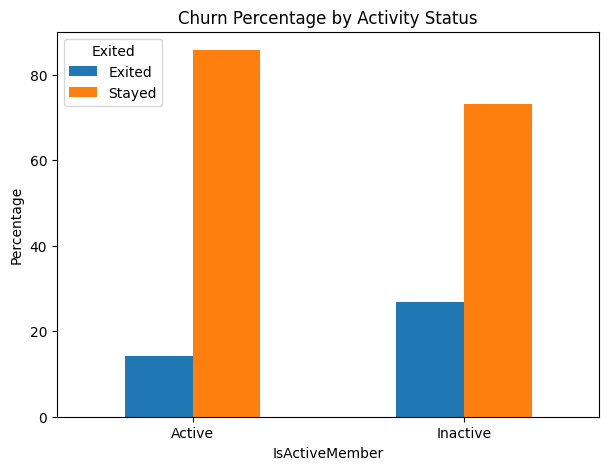

In [ ]:
activity_churn.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Churn Percentage by Activity Status")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

churn with resp to number of products

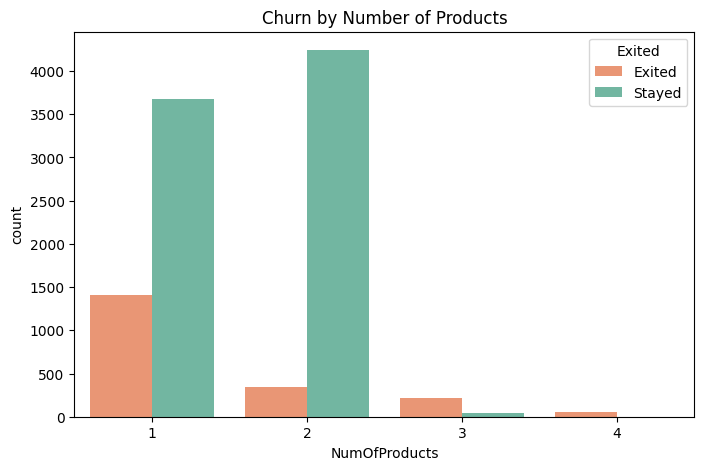

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="NumOfProducts",
    hue="Exited",
    palette={"Stayed": "#66c2a5", "Exited": "#fc8d62"}
)

plt.title("Churn by Number of Products")

plt.show()

churn percentage

In [ ]:
product_churn = (
    pd.crosstab(df["NumOfProducts"], df["Exited"], normalize="index") * 100
).round(2)

product_churn

Exited,Exited,Stayed
NumOfProducts,,
1,27.71,72.29
2,7.58,92.42
3,82.71,17.29
4,100.00,0.00


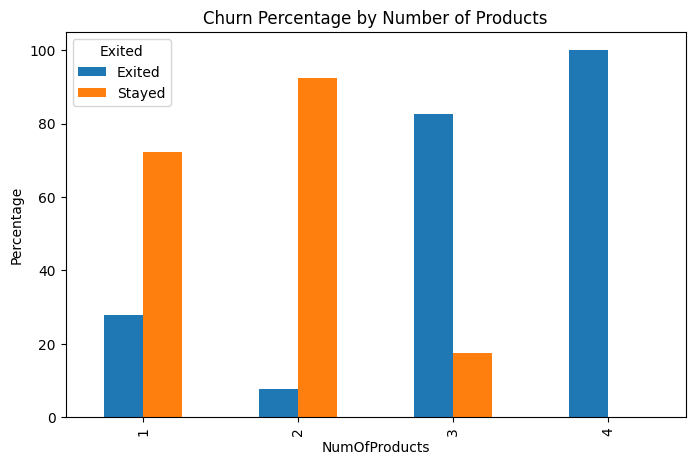

In [ ]:
product_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Percentage by Number of Products")
plt.ylabel("Percentage")

plt.show()

churn rate with resp to tenure

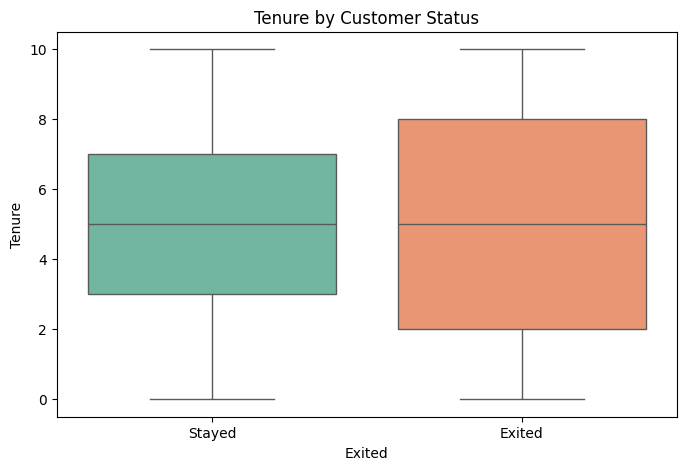

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Exited",
    y="Tenure",
    order=["Stayed", "Exited"],
    palette="Set2"
)

plt.title("Tenure by Customer Status")

plt.show()

average tenure

In [ ]:
df.groupby("Exited")["Tenure"].mean().round(2)

,Tenure
Exited,
Exited,4.93
Stayed,5.03


Average balance

In [ ]:
df.groupby("Exited")["Balance"].mean().round(2)

,Balance
Exited,
Exited,91108.54
Stayed,72745.30


Credit card churn table

In [ ]:
creditcard_churn = (
    pd.crosstab(df["HasCrCard"], df["Exited"], normalize="index") * 100
).round(2)

creditcard_churn

Exited,Exited,Stayed
HasCrCard,,
No,20.81,79.19
Yes,20.18,79.82


Average estimated salarey

In [ ]:
df.groupby("Exited")["EstimatedSalary"].mean().round(2)

,EstimatedSalary
Exited,
Exited,101465.68
Stayed,99738.39


Number of costumers churn with each product count

In [ ]:
df["NumOfProducts"].value_counts().sort_index()

,count
NumOfProducts,
1,5084
2,4590
3,266
4,60


CORRELATION ANALYSIS

Converting lables back to numeric (temporarily)

In [ ]:
df_corr = df.copy()

df_corr["Exited"] = df_corr["Exited"].map({"Stayed": 0, "Exited": 1})

df_corr["HasCrCard"] = df_corr["HasCrCard"].map({"No": 0, "Yes": 1})

df_corr["IsActiveMember"] = df_corr["IsActiveMember"].map({"Inactive": 0, "Active": 1})

df_corr["Gender"] = df_corr["Gender"].map({"Female": 0, "Male": 1})

One-Hot encode geography

In [ ]:
df_corr = pd.get_dummies(df_corr, columns=["Geography"], drop_first=True)

Correlation Matrix

In [ ]:
corr = df_corr.corr()

corr

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
CreditScore,1.000000,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
Gender,-0.002857,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512,-0.024628,0.016889
Age,-0.003965,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
Tenure,0.000842,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
Balance,0.006268,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892
NumOfProducts,0.012238,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
HasCrCard,-0.005458,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
IsActiveMember,0.025651,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
EstimatedSalary,-0.001384,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482
Exited,-0.027094,-0.106512,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667


Heatmap

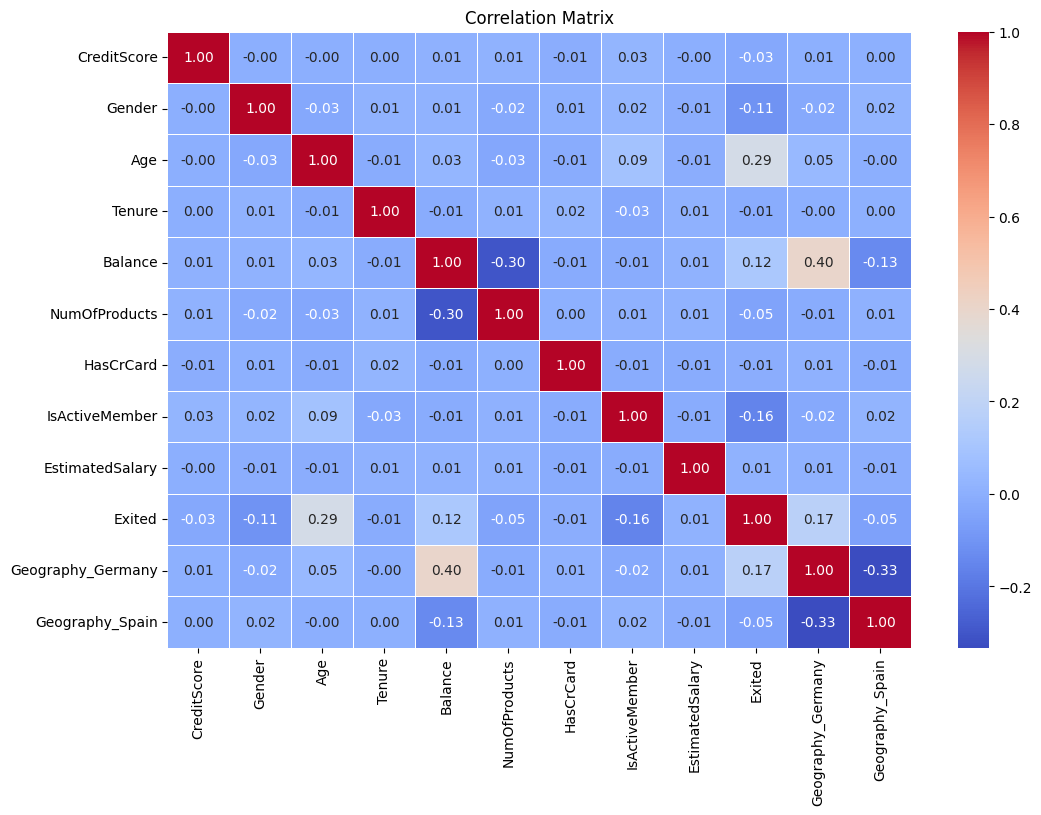

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

Correlation with Churn

In [ ]:
corr["Exited"].drop("Exited").sort_values(ascending=False)

,Exited
Age,0.285323
Geography_Germany,0.173488
Balance,0.118533
EstimatedSalary,0.012097
HasCrCard,-0.007138
Tenure,-0.014001
CreditScore,-0.027094
NumOfProducts,-0.047820
Geography_Spain,-0.052667
Gender,-0.106512


ROOT CAUSE ANALYSIS

Creating the churn risk score

1. Age groups

In [ ]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18,30,40,50,100],
    labels=["Young","Adult","Middle Age","Senior"]
)

df["AgeGroup"].value_counts()

,count
AgeGroup,
Adult,4451
Middle Age,2320
Young,1946
Senior,1261


2. Credit score category

In [ ]:
df["CreditScoreGroup"] = pd.cut(
    df["CreditScore"],
    bins=[300,580,670,740,850],
    labels=["Poor","Fair","Good","Excellent"]
)

df["CreditScoreGroup"].value_counts()

,count
CreditScoreGroup,
Fair,3350
Good,2397
Poor,2393
Excellent,1860


3. Tenure category

In [ ]:
df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=[-1,3,7,10],
    labels=["New","Regular","Loyal"]
)

df["TenureGroup"].value_counts()

,count
TenureGroup,
Regular,3996
New,3505
Loyal,2499


4. Customer value

In [ ]:
df["CustomerValue"] = np.where(
    (df["Balance"] > df["Balance"].median()) &
    (df["NumOfProducts"] >= 2),
    "High Value",
    "Regular"
)

df["CustomerValue"].value_counts()

,count
CustomerValue,
Regular,8298
High Value,1702


5. Balance category

In [ ]:
df["BalanceGroup"] = pd.cut(
    df["Balance"],
    bins=[-1, 0, 100000, 250000],
    labels=["Zero Balance", "Low Balance", "High Balance"]
)

df["BalanceGroup"].value_counts()

,count
BalanceGroup,
High Balance,4798
Zero Balance,3617
Low Balance,1584


DATA PRE-PROCESSING AND MACHINE LEARNING

Create a Separate ML Dataset

We don't want to modify our original df because we'll still use it for Power BI later.

In [ ]:
ml_df = df.copy()

In [ ]:
ml_df["Exited"] = ml_df["Exited"].map({
    "Stayed":0,
    "Exited":1
})

In [ ]:
ml_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditScoreGroup,TenureGroup,CustomerValue,BalanceGroup
0,619,France,Female,42,2,0.00,1,Yes,Active,101348.88,1,Middle Age,Fair,New,Regular,Zero Balance
1,608,Spain,Female,41,1,83807.86,1,No,Active,112542.58,0,Middle Age,Fair,New,Regular,Low Balance
2,502,France,Female,42,8,159660.80,3,Yes,Inactive,113931.57,1,Middle Age,Poor,Loyal,High Value,High Balance
3,699,France,Female,39,1,0.00,2,No,Inactive,93826.63,0,Adult,Good,New,Regular,Zero Balance
4,850,Spain,Female,43,2,125510.82,1,Yes,Active,79084.10,0,Middle Age,Excellent,New,Regular,High Balance


In [ ]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   CreditScore       10000 non-null  int64   
 1   Geography         10000 non-null  object  
 2   Gender            10000 non-null  object  
 3   Age               10000 non-null  int64   
 4   Tenure            10000 non-null  int64   
 5   Balance           10000 non-null  float64 
 6   NumOfProducts     10000 non-null  int64   
 7   HasCrCard         10000 non-null  object  
 8   IsActiveMember    10000 non-null  object  
 9   EstimatedSalary   10000 non-null  float64 
 10  Exited            10000 non-null  int64   
 11  AgeGroup          9978 non-null   category
 12  CreditScoreGroup  10000 non-null  category
 13  TenureGroup       10000 non-null  category
 14  CustomerValue     10000 non-null  object  
 15  BalanceGroup      9999 non-null   category
dtypes: category(4), float64

In [ ]:
ml_df = pd.get_dummies(
    ml_df,
    drop_first=True
)
ml_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_Yes,IsActiveMember_Inactive,AgeGroup_Adult,AgeGroup_Middle Age,AgeGroup_Senior,CreditScoreGroup_Fair,CreditScoreGroup_Good,CreditScoreGroup_Excellent,TenureGroup_Regular,TenureGroup_Loyal,CustomerValue_Regular,BalanceGroup_Low Balance,BalanceGroup_High Balance
0,619,42,2,0.00,1,101348.88,1,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False
1,608,41,1,83807.86,1,112542.58,0,False,True,False,False,False,False,True,False,True,False,False,False,False,True,True,False
2,502,42,8,159660.80,3,113931.57,1,False,False,False,True,True,False,True,False,False,False,False,False,True,False,False,True
3,699,39,1,0.00,2,93826.63,0,False,False,False,False,True,True,False,False,False,True,False,False,False,True,False,False
4,850,43,2,125510.82,1,79084.10,0,False,True,False,True,False,False,True,False,False,False,True,False,False,True,False,True


Separating features and target

In [ ]:
X = ml_df.drop("Exited", axis=1)

y = ml_df["Exited"]

In [ ]:
print(X.shape)
print(y.shape)

(10000, 22)
(10000,)


Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training:", X_train.shape)

print("Testing:", X_test.shape)

Training: (8000, 22)
Testing: (2000, 22)


Scaling the data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

MODEL 1: LOGISTIC REGRESSION (baseline)

1. Importing libraies

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

2. Training the model

In [ ]:
lr_model = LogisticRegression(
    random_state=42,
    class_weight="balanced"
)

lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

3. making the predictions

In [ ]:
y_pred = lr_model.predict(X_test_scaled)

y_prob = lr_model.predict_proba(X_test_scaled)[:,1]

4. Model evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.7200
Precision: 0.3979
Recall   : 0.7322
F1 Score : 0.5156
ROC AUC  : 0.7899


5. Classification report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1593
           1       0.40      0.73      0.52       407

    accuracy                           0.72      2000
   macro avg       0.66      0.72      0.66      2000
weighted avg       0.81      0.72      0.74      2000



6. confusion matrix

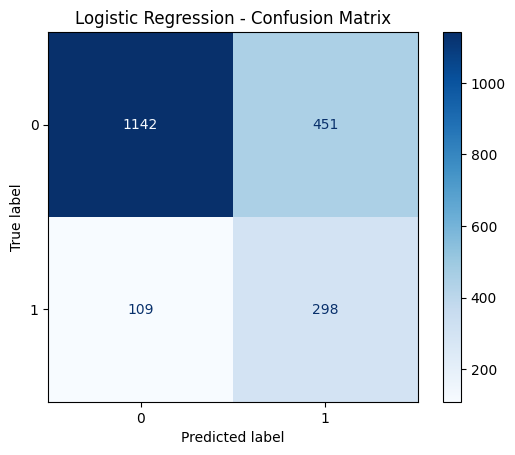

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

7. ROC curve

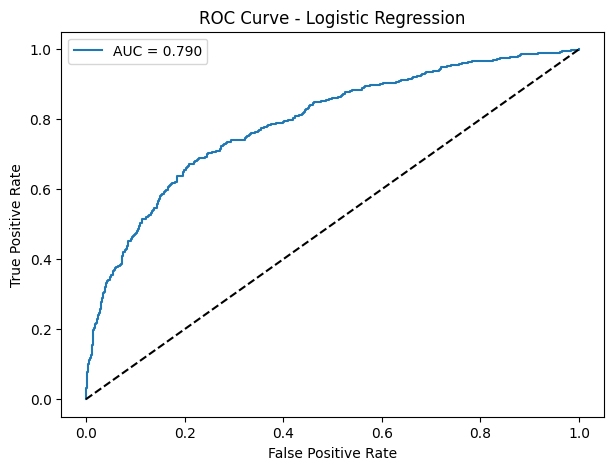

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

8. Feature importance

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient
13,AgeGroup_Senior,0.735092
12,AgeGroup_Middle Age,0.723811
10,IsActiveMember_Inactive,0.435785
6,Geography_Germany,0.343931
21,BalanceGroup_High Balance,0.336678
8,Gender_Male,-0.277209
11,AgeGroup_Adult,0.243473
0,CreditScore,-0.222252
16,CreditScoreGroup_Excellent,0.181372
19,CustomerValue_Regular,0.157228


MODEL 2: DECISION TREE

1. Importing the model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

2. training the model

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

3. Predictions

In [ ]:
y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:,1]

4. Evaluation

In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(y_test, y_pred_dt)

recall_dt = recall_score(y_test, y_pred_dt)

f1_dt = f1_score(y_test, y_pred_dt)

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"ROC AUC  : {roc_auc_dt:.4f}")

Accuracy : 0.7905
Precision: 0.4864
Recall   : 0.5283
F1 Score : 0.5065
ROC AUC  : 0.6929


5. Classification report

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1593
           1       0.49      0.53      0.51       407

    accuracy                           0.79      2000
   macro avg       0.68      0.69      0.69      2000
weighted avg       0.80      0.79      0.79      2000



6. Confusion matrix

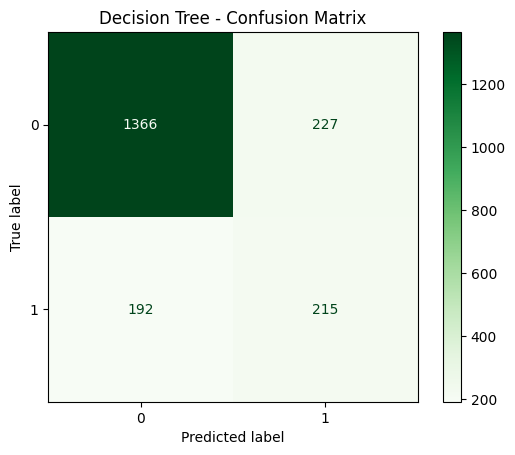

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Greens"
)

plt.title("Decision Tree - Confusion Matrix")

plt.show()

7. ROC Curve

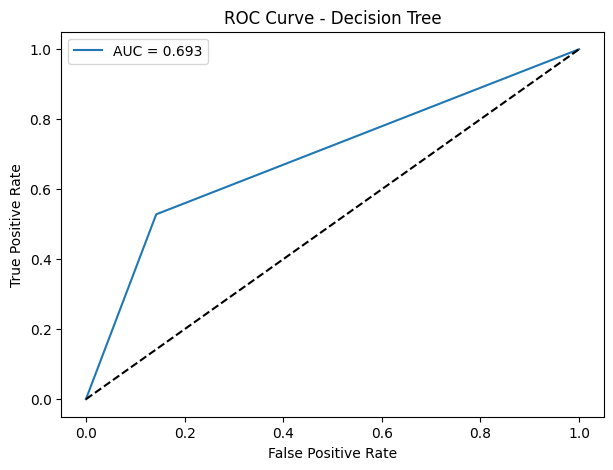

In [ ]:
fpr_dt, tpr_dt, thresholds_dt = roc_curve(
    y_test,
    y_prob_dt
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"AUC = {roc_auc_dt:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.show()

8. Feature Importance

In [ ]:
feature_importance_dt = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance_dt = feature_importance_dt.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_dt.head(15)

,Feature,Importance
1,Age,0.194701
5,EstimatedSalary,0.149287
3,Balance,0.141134
0,CreditScore,0.126012
4,NumOfProducts,0.117807
2,Tenure,0.064515
10,IsActiveMember_Inactive,0.061545
12,AgeGroup_Middle Age,0.029697
6,Geography_Germany,0.023620
8,Gender_Male,0.021138


MODEL 3: RANDOM FOREST

1. Import SMOTE

In [ ]:
from sklearn.ensemble import RandomForestClassifier

2. Create the model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

3. Train the model

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

4. Predictions

In [ ]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

5. Evaluation

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC AUC  : {roc_auc_rf:.4f}")

Accuracy : 0.8285
Precision: 0.5648
Recall   : 0.6855
F1 Score : 0.6193
ROC AUC  : 0.8601


6. classification report

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1593
           1       0.56      0.69      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.84      0.83      0.83      2000



7. Confusion matrix

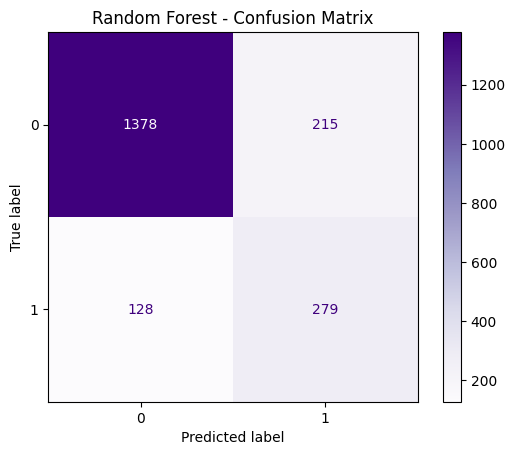

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Purples"
)

plt.title("Random Forest - Confusion Matrix")

plt.show()



8. ROC Curve

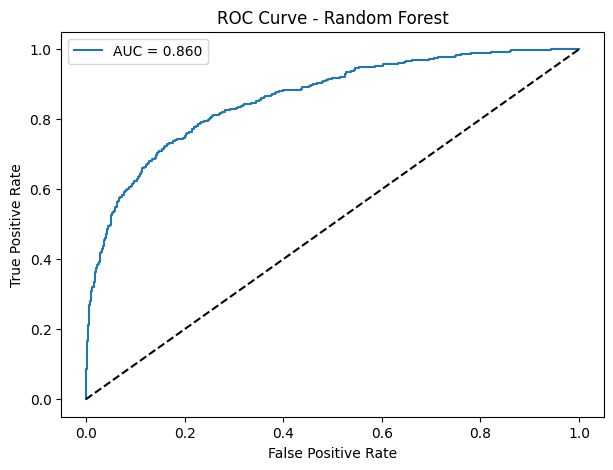

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"AUC = {roc_auc_rf:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

9. Feature importance

In [ ]:
feature_importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_rf.head(20)

,Feature,Importance
1,Age,0.242666
4,NumOfProducts,0.174139
3,Balance,0.087800
5,EstimatedSalary,0.061785
0,CreditScore,0.058053
10,IsActiveMember_Inactive,0.056622
13,AgeGroup_Senior,0.051163
6,Geography_Germany,0.046838
12,AgeGroup_Middle Age,0.035200
2,Tenure,0.033628


10. Visualise feature importance

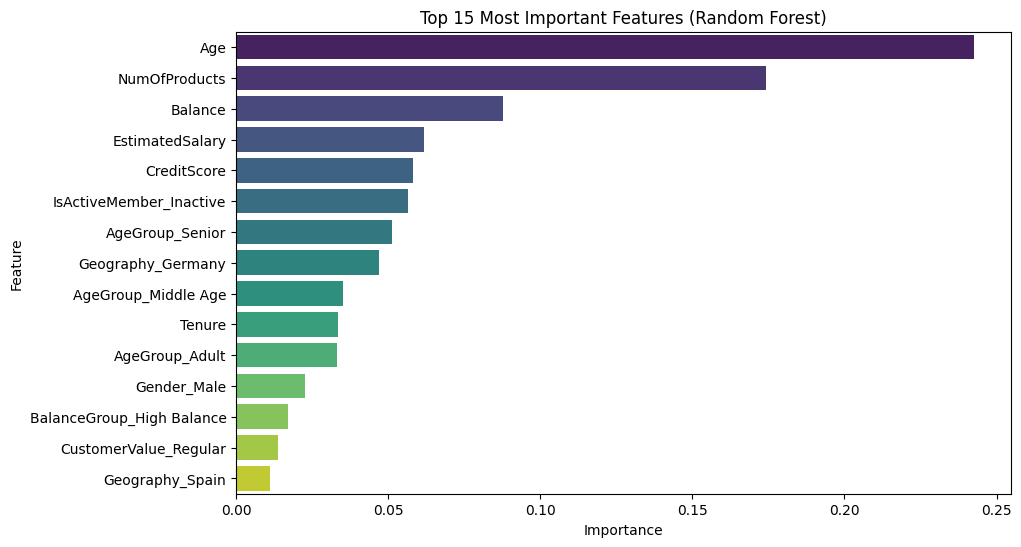

In [ ]:
top_features = feature_importance_rf.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

MODEL 4: XG BOOST

1. Installing XGBoost

In [ ]:
!pip install xgboost -q

2. Importing libraries

In [ ]:
from xgboost import XGBClassifier

3. Create the model

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

4. Training the model

In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

5. Predictions

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

6. Evaluate

In [ ]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

precision_xgb = precision_score(y_test, y_pred_xgb)

recall_xgb = recall_score(y_test, y_pred_xgb)

f1_xgb = f1_score(y_test, y_pred_xgb)

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")
print(f"ROC AUC  : {roc_auc_xgb:.4f}")

Accuracy : 0.8605
Precision: 0.7388
Recall   : 0.4865
F1 Score : 0.5867
ROC AUC  : 0.8522


7. Classification Report

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.74      0.49      0.59       407

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



8. Confusion Matrix

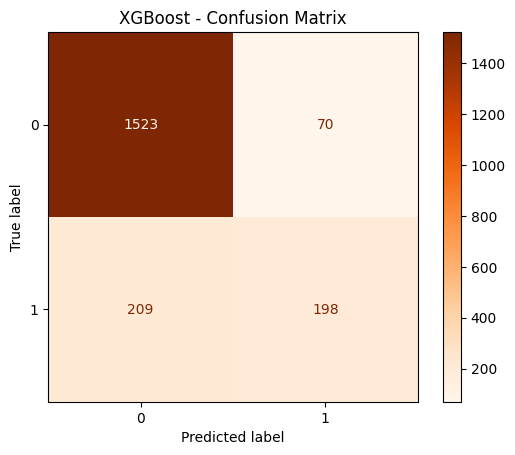

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Oranges"
)

plt.title("XGBoost - Confusion Matrix")

plt.show()

9. ROC Curve

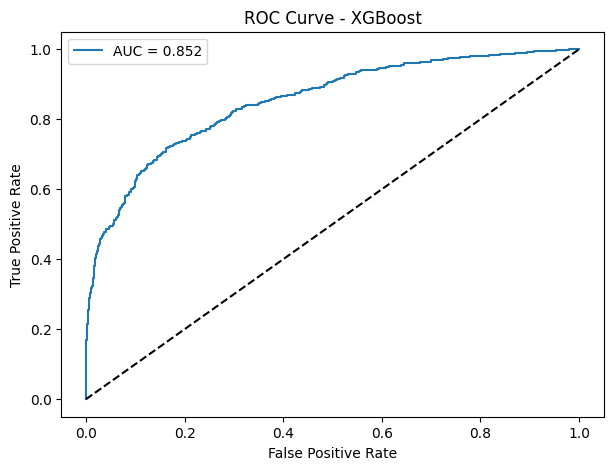

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"AUC = {roc_auc_xgb:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()

10. Feature importance

In [ ]:
feature_importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb.head(20)

,Feature,Importance
4,NumOfProducts,0.196966
13,AgeGroup_Senior,0.127609
10,IsActiveMember_Inactive,0.090156
12,AgeGroup_Middle Age,0.075825
1,Age,0.065221
6,Geography_Germany,0.051798
21,BalanceGroup_High Balance,0.050384
3,Balance,0.032911
20,BalanceGroup_Low Balance,0.029991
8,Gender_Male,0.028210


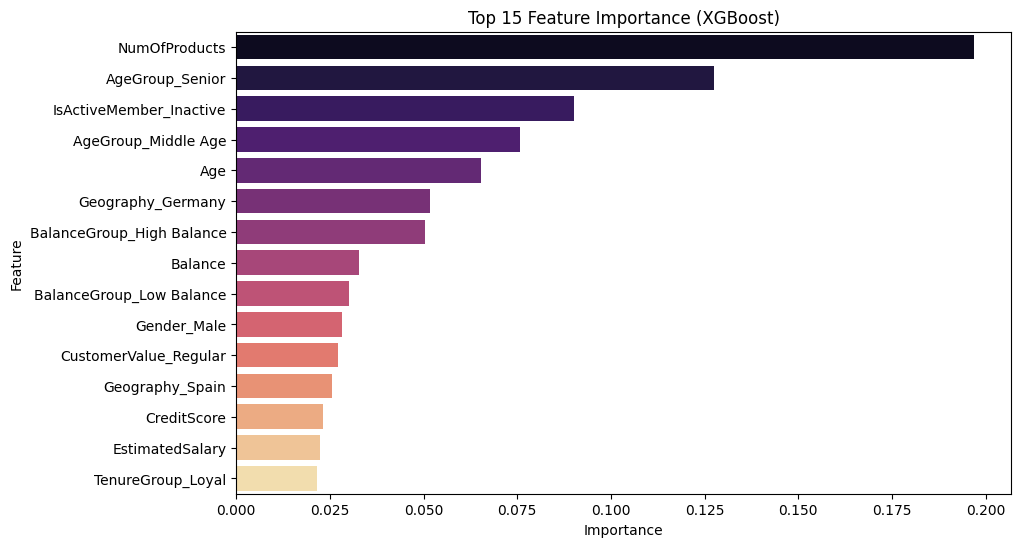

In [ ]:
top_features = feature_importance_xgb.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="magma"
)

plt.title("Top 15 Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

In [ ]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
print(random_search.best_params_)

{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [ ]:
best_xgb = random_search.best_estimator_

In [ ]:
y_pred_best = best_xgb.predict(X_test)

y_prob_best = best_xgb.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best))

Accuracy : 0.8625
Precision: 0.7578125
Recall   : 0.47665847665847666
F1 Score : 0.5852187028657617
ROC AUC  : 0.8629893375656087


FINAL MODEL COMPAIRISION TABLE

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[0.8315,0.7905,0.8285,0.8605],
    "Precision":[0.7188,0.4864,0.5648,0.7388],
    "Recall":[0.2826,0.5283,0.6855,0.4865],
    "F1 Score":[0.4056,0.5065,0.6193,0.5867],
    "ROC-AUC":[0.7912,0.6929,0.8601,0.8522],
    "Selected":[
        "",
        "",
        "Final Model",
        ""
    ]
})

comparison
comparison.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    color="#000000"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Selected
0,Logistic Regression,0.831500,0.718800,0.282600,0.405600,0.791200,
1,Decision Tree,0.790500,0.486400,0.528300,0.506500,0.692900,
2,Random Forest,0.828500,0.564800,0.685500,0.619300,0.860100,Final Model
3,XGBoost,0.860500,0.738800,0.486500,0.586700,0.852200,


Four machine learning models were evaluated for customer churn prediction: Logistic Regression, Decision Tree, Random Forest, and XGBoost.

XGBoost achieved the highest overall accuracy (86.05%) and precision (73.88%). However, its recall (48.65%) was significantly lower than that of the Random Forest model (68.55%).

Since the primary objective of this project is to identify customers who are likely to churn so that the bank can proactively intervene, recall was considered one of the most important evaluation metrics. A model with higher recall identifies more customers at risk of leaving, reducing the likelihood of missing potential churners.

Random Forest achieved the best balance between Recall (68.55%), F1-score (61.93%), and ROC-AUC (86.01%) while maintaining competitive accuracy (82.85%). Therefore, Random Forest was selected as the final model for deployment and business decision-making.

In [ ]:
playbook = df.copy()

In [ ]:
playbook["Churn_Probability"] = rf_model.predict_proba(X)[:,1]

playbook["Predicted_Churn"] = rf_model.predict(X)

In [ ]:
def risk(prob):
    if prob >= 0.75:
        return "High"
    elif prob >= 0.50:
        return "Medium"
    else:
        return "Low"

playbook["Risk_Level"] = playbook["Churn_Probability"].apply(risk)

In [ ]:
def reason(row):

    if row["IsActiveMember"] == 0:
        return "Inactive Customer"

    elif row["Age"] >= 50:
        return "Senior Customer"

    elif row["Geography"] == "Germany":
        return "Germany Region"

    elif row["NumOfProducts"] == 1:
        return "Single Product"

    elif row["Balance"] > df["Balance"].median():
        return "High Balance"

    else:
        return "General Monitoring"

playbook["Top_Reason"] = playbook.apply(reason, axis=1)

In [ ]:
def action(reason):

    actions = {
        "Inactive Customer": "Launch Re-engagement Campaign",
        "Senior Customer": "Offer Senior Loyalty Program",
        "Germany Region": "Investigate Regional Churn",
        "Single Product": "Cross-sell Banking Products",
        "High Balance": "Assign Relationship Manager",
        "General Monitoring": "Regular Monitoring"
    }

    return actions[reason]

playbook["Recommended_Action"] = playbook["Top_Reason"].apply(action)

In [ ]:
priority_map = {
    "High": "High",
    "Medium": "Medium",
    "Low": "Low"
}

playbook["Priority"] = playbook["Risk_Level"].map(priority_map)

In [ ]:
def followup(risk):

    if risk == "High":
        return "Within 24 Hours"

    elif risk == "Medium":
        return "Within 7 Days"

    else:
        return "Monthly Monitoring"

playbook["Follow_Up"] = playbook["Risk_Level"].apply(followup)

In [ ]:
def team(reason):

    if reason in [
        "Inactive Customer",
        "High Balance"
    ]:
        return "Retention Team"

    elif reason == "Germany Region":
        return "Regional Operations"

    elif reason == "Single Product":
        return "Sales Team"

    else:
        return "Customer Success"

playbook["Assigned_Team"] = playbook["Top_Reason"].apply(team)

In [ ]:
final_playbook["Churn_Probability"] = (
    final_playbook["Churn_Probability"] * 100
).round(2)

In [ ]:
final_playbook = playbook[
[
    "Age",
    "Geography",
    "Gender",
    "Balance",
    "NumOfProducts",
    "IsActiveMember",
    "Churn_Probability",
    "Risk_Level",
    "Top_Reason",
    "Recommended_Action",
    "Follow_Up",
    "Assigned_Team",
    "Priority"
]
].sort_values(
    by="Churn_Probability",
    ascending=False
)

final_playbook.head(20)

,Age,Geography,Gender,Balance,NumOfProducts,IsActiveMember,Churn_Probability,Risk_Level,Top_Reason,Recommended_Action,Follow_Up,Assigned_Team,Priority
8923,55,Germany,Female,118772.71,4,Inactive,0.977817,High,Senior Customer,Offer Senior Loyalty Program,Within 24 Hours,Customer Success,High
7533,51,Germany,Female,108449.23,3,Inactive,0.969080,High,Senior Customer,Offer Senior Loyalty Program,Within 24 Hours,Customer Success,High
1265,55,France,Female,116973.26,3,Inactive,0.968706,High,Senior Customer,Offer Senior Loyalty Program,Within 24 Hours,Customer Success,High
8363,57,Germany,Male,120043.13,1,Inactive,0.968125,High,Senior Customer,Offer Senior Loyalty Program,Within 24 Hours,Customer Success,High
2614,58,Germany,Female,106458.31,4,Inactive,0.967983,High,Senior Customer,Offer Senior Loyalty Program,Within 24 Hours,Customer Success,High
2106,55,Germany,Female,123378.20,1,Inactive,0.967745,High,Senior Customer,Offer Senior Loyalty Program,Within 24 Hours,Customer Success,High
7213,55,Germany,Female,149349.58,3,Inactive,0.962633,High,Senior Customer,Offer Senior Loyalty Program,Within 24 Hours,Customer Success,High
6274,52,Germany,Male,110791.97,1,Inactive,0.962626,High,Senior Customer,Offer Senior Loyalty Program,Within 24 Hours,Customer Success,High
2575,54,Germany,Male,102994.04,1,Inactive,0.960745,High,Senior Customer,Offer Senior Loyalty Program,Within 24 Hours,Customer Success,High
4054,56,France,Female,115895.22,3,Inactive,0.960428,High,Senior Customer,Offer Senior Loyalty Program,Within 24 Hours,Customer Success,High


In [ ]:
final_playbook.to_excel(
    "Churn_Playbook_Professional.xlsx",
    index=False
)

print("Professional Churn Playbook Created!")

Professional Churn Playbook Created!


In [ ]:
from google.colab import files

files.download("Churn_Playbook_Professional.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

This project developed an end-to-end customer churn prediction framework using machine learning and business analytics techniques.

After evaluating Logistic Regression, Decision Tree, Random Forest, and XGBoost models, Random Forest was selected as the final model because it achieved the best balance between Recall (68.55%), F1-score (61.93%), and ROC-AUC (86.01%), making it the most suitable model for identifying customers at risk of churn.

The project demonstrates how predictive analytics can be combined with business intelligence to support customer retention strategies and data-driven decision-making in the banking sector.